In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

In [2]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

X.head()

Features Shape: (569, 30)
Target Shape: (569,)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Class Distribution:

1    357
0    212
Name: count, dtype: int64


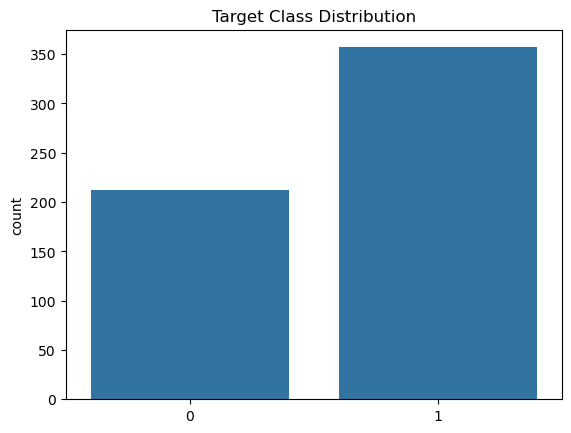

In [3]:
print("Class Distribution:\n")
print(pd.Series(y).value_counts())

sns.countplot(x=y)
plt.title("Target Class Distribution")
plt.show()

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 455
Testing Samples: 114


In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
log_model = LogisticRegression(max_iter=5000)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:,1]

In [7]:
accuracy_log = accuracy_score(y_test, y_pred_log)

print("Logistic Regression Accuracy:", accuracy_log)

Logistic Regression Accuracy: 0.9824561403508771


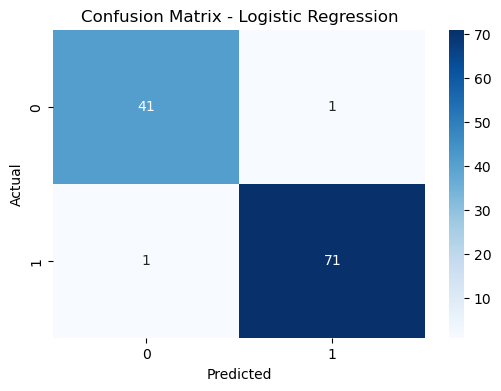

In [8]:
cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [9]:
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



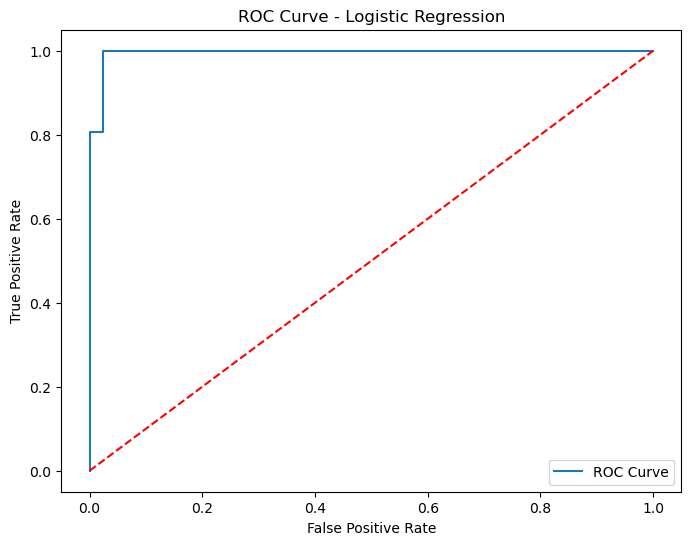

In [10]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_log)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")

plt.legend()
plt.show()

In [11]:
auc_log = roc_auc_score(y_test, y_prob_log)

print("AUC Score:", auc_log)

AUC Score: 0.9953703703703703


In [12]:
tree_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)
y_prob_tree = tree_model.predict_proba(X_test)[:,1]

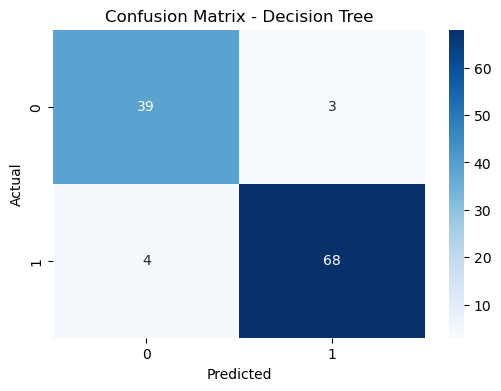

In [13]:
cm = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(6,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree")
plt.show()

In [14]:
print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       0.91      0.93      0.92        42
           1       0.96      0.94      0.95        72

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



In [15]:
accuracy_tree = accuracy_score(y_test, y_pred_tree)

print("Decision Tree Accuracy:", accuracy_tree)

Decision Tree Accuracy: 0.9385964912280702


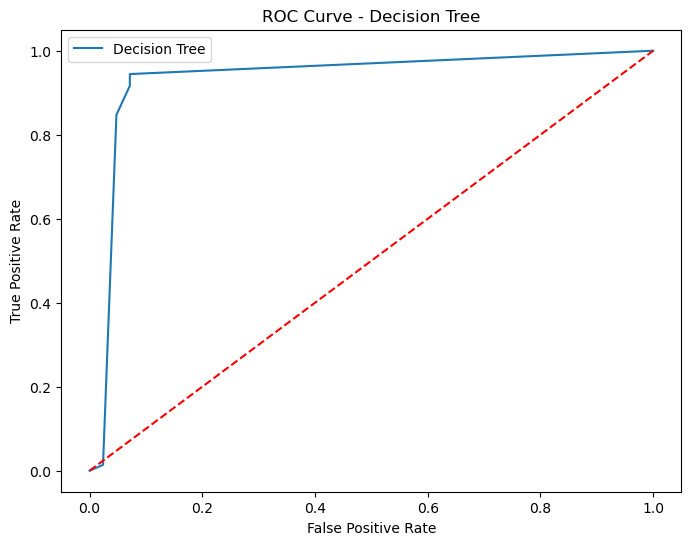

In [16]:
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)

plt.figure(figsize=(8,6))

plt.plot(fpr_tree, tpr_tree,
         label='Decision Tree')

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")

plt.legend()
plt.show()

In [17]:
auc_tree = roc_auc_score(y_test, y_prob_tree)

print("Decision Tree AUC:", auc_tree)

Decision Tree AUC: 0.9341931216931217


In [18]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree"
    ],
    "Accuracy": [
        accuracy_log,
        accuracy_tree
    ],
    "AUC Score": [
        auc_log,
        auc_tree
    ]
})

comparison

,Model,Accuracy,AUC Score
0,Logistic Regression,0.982456,0.995370
1,Decision Tree,0.938596,0.934193


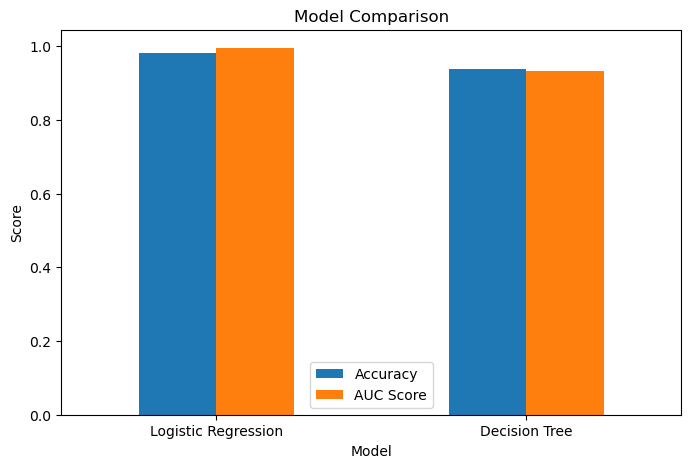

In [19]:
comparison.set_index("Model").plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

In [20]:
from sklearn.datasets import make_classification

X_imb, y_imb = make_classification(
    n_samples=5000,
    n_features=20,
    n_classes=2,
    weights=[0.95,0.05],
    random_state=42
)

pd.Series(y_imb).value_counts()

0    4724
1     276
Name: count, dtype: int64

In [21]:
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_imb,
    y_imb,
    test_size=0.2,
    random_state=42,
    stratify=y_imb
)

In [22]:
normal_model = LogisticRegression(max_iter=5000)

normal_model.fit(X_train_i, y_train_i)

pred_normal = normal_model.predict(X_test_i)

print("Without Class Weight\n")
print(classification_report(y_test_i, pred_normal))

Without Class Weight

              precision    recall  f1-score   support

           0       0.96      0.99      0.98       945
           1       0.67      0.36      0.47        55

    accuracy                           0.95      1000
   macro avg       0.82      0.68      0.72      1000
weighted avg       0.95      0.95      0.95      1000



In [23]:
weighted_model = LogisticRegression(
    class_weight='balanced',
    max_iter=5000
)

weighted_model.fit(X_train_i, y_train_i)

pred_weighted = weighted_model.predict(X_test_i)

print("With Class Weight = Balanced\n")
print(classification_report(y_test_i, pred_weighted))

With Class Weight = Balanced

              precision    recall  f1-score   support

           0       0.99      0.85      0.91       945
           1       0.23      0.78      0.36        55

    accuracy                           0.85      1000
   macro avg       0.61      0.82      0.64      1000
weighted avg       0.94      0.85      0.88      1000



In [24]:
print("""
Conclusion

1. Logistic Regression performed exceptionally well
   on the Breast Cancer dataset.

2. ROC-AUC score showed excellent discrimination
   between classes.

3. Decision Tree achieved competitive performance
   but was slightly less stable.

4. Accuracy alone is not sufficient when classes
   are imbalanced.

5. Precision, Recall and F1-score provide a better
   understanding of model performance.

6. Using class_weight='balanced' improved minority
   class detection in imbalanced datasets.

7. Logistic Regression was selected as the best
   model because of higher AUC, better generalization
   and interpretability.
""")


Conclusion

1. Logistic Regression performed exceptionally well
   on the Breast Cancer dataset.

2. ROC-AUC score showed excellent discrimination
   between classes.

3. Decision Tree achieved competitive performance
   but was slightly less stable.

4. Accuracy alone is not sufficient when classes
   are imbalanced.

5. Precision, Recall and F1-score provide a better
   understanding of model performance.

6. Using class_weight='balanced' improved minority
   class detection in imbalanced datasets.

7. Logistic Regression was selected as the best
   model because of higher AUC, better generalization
   and interpretability.

